# 04 — Evaluation on the test set

How well does the adopted pipeline find, segment and count the cells in **70 images it has never seen**, and how does it
compare with other methods?

- The test set (70 images, 1172 annotated cells) was never used to train anything or to make any choice: all the choices are
  in notebooks 02 and 03 (training, validation and cross-validation images).
- **Nothing is trained in this notebook.** For every method we only load weights or parameters that were fixed before, and
  predict. Cellpose is too heavy for a CPU (it ran on a Kaggle GPU), so its predictions are loaded directly. How each
  method was trained or tuned is in `other_methods/`.
- At the end of each section an `assert` checks that the numbers are exactly the reference ones (`runs/test_reference.json`).

Runs on CPU in about 10 minutes.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage import measure
from skimage.draw import disk
from skimage.filters import threshold_otsu
from skimage.segmentation import relabel_sequential

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from evaluation.detection import counter_metrics, match_centres
from evaluation.metrics import overlap_tables
from evaluation.object_classifier import keep_objects
from evaluation.object_features import FEATURES, label_objects
from evaluation.postprocess import clean_instances, label_instances, postprocess, predict_labels
from evaluation.predict import load_model, predict_probs
from evaluation.tune import counts_row, metrics_from_counts
from evaluation.watershed_classifier import MIN_DISTANCE, delivered_labels
from other_methods.threshold_baseline import robust_threshold, signal_channel
from train.dataset import GreenEvalDataset, load_img_and_masks

IMG_DIR = Path("data/green/test/images")
MASK_DIR = Path("data/cleaned_masks/test/Green/masks")
RUN = Path("runs/green_v2")
REFERENCE = json.load(open("runs/test_reference.json"))

## 1. The test images

In [2]:
names = sorted(p.name for p in IMG_DIR.glob("*.png"))
images, masks = load_img_and_masks(IMG_DIR, MASK_DIR, names)
true_masks = masks > 0
true_labels = [label_instances(m) for m in true_masks]
n_cells = sum(int(labels.max()) for labels in true_labels)
print(f"{len(names)} test images, {n_cells} annotated cells")

70 test images, 1172 annotated cells


## 2. Step 1: from the images to probability maps

The adopted network (`runs/green_v2/best.pt`, epoch 79), with the normalization saved in its checkpoint.

In [3]:
model, mean, std, epoch, norm = load_model(RUN / "best.pt", torch.device("cpu"))
dataset = GreenEvalDataset(images, masks, names, mean, std, norm=norm)
start = time.time()
probs, _ = predict_probs(model, dataset, torch.device("cpu"))
probs = probs.astype(np.float32)
print(f"{len(probs)} probability maps in {time.time() - start:.0f} s")

70 probability maps in 297 s


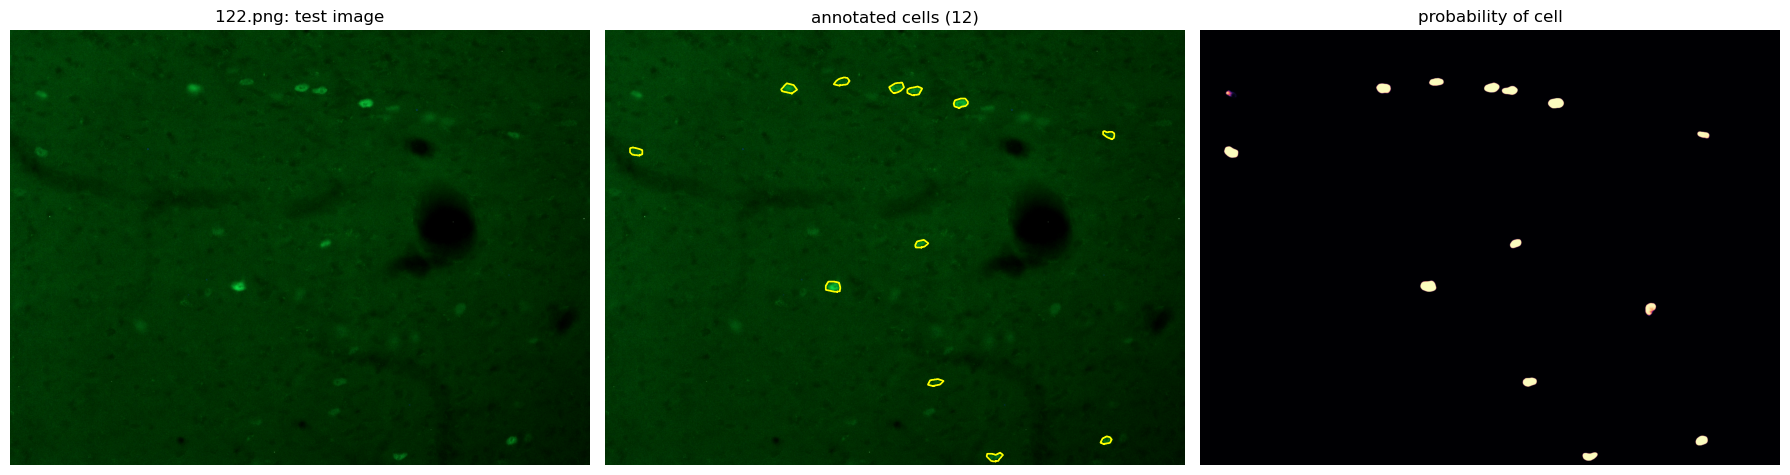

In [4]:
def outline(ax, mask, color, width=1.2):
    '''Draw the outline of the objects of a mask.'''
    for contour in measure.find_contours(np.asarray(mask) > 0, 0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=width)

def show(image):
    '''Image for display: same brightness scale for every image.'''
    return np.clip(image / 150, 0, 1)

# an image with a typical number of cells
cells_per_image = [int(labels.max()) for labels in true_labels]
i = int(np.argsort(cells_per_image)[len(names) // 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].imshow(show(images[i]))
axes[0].set_title(f"{names[i]}: test image")
axes[1].imshow(show(images[i]))
outline(axes[1], true_masks[i], "yellow")
axes[1].set_title(f"annotated cells ({cells_per_image[i]})")
axes[2].imshow(probs[i], cmap="magma")
axes[2].set_title("probability of cell")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Step 2: from probability maps to cells

The adopted pipeline (notebook 03), image by image, with the same function used on the validation images:
threshold 0.5 → fill holes → objects < 120 px removed → watershed (seeds ≥ 20 px apart) → frozen object classifier
(logistic regression, keep if P(true) ≥ 0.34; objects on the border always kept).

In [5]:
classifier = joblib.load(RUN / "object_classifier_ws20" / "classifier.joblib")

adopted_labels, adopted_tables = [], []
for i in range(len(names)):
    labels, table = delivered_labels(probs[i], images[i], true_labels[i], i, classifier)
    adopted_labels.append(labels)
    adopted_tables.append(table)
print(f"cells found by the adopted pipeline: {sum(int(labels.max()) for labels in adopted_labels)}")

cells found by the adopted pipeline: 1292


The steps on one region of a test image where two touching cells are split by the watershed (in this region the classifier
keeps every object):

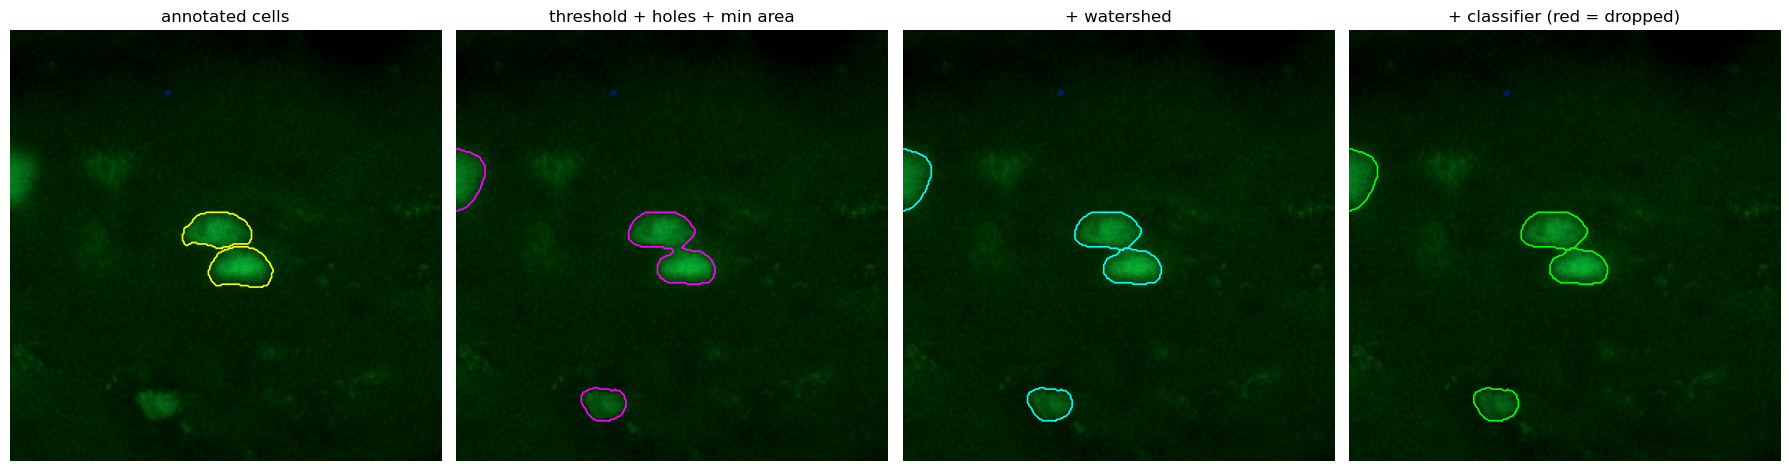

In [6]:
# a region where the watershed splits an object that covers two annotated cells
example = None
for i in range(len(names)):
    before = label_instances(postprocess(probs[i], 0.5))
    after = predict_labels(probs[i], 0.5, min_distance=MIN_DISTANCE)
    for region in measure.regionprops(before):
        cells_under = np.unique(true_labels[i][before == region.label])
        pieces_after = np.unique(after[before == region.label])
        if len(cells_under[cells_under > 0]) >= 2 and len(pieces_after[pieces_after > 0]) >= 2:
            example = (i, region, before, after)
            break
    if example is not None:
        break

i, region, before, after = example
r, c = region.centroid
r0 = int(min(max(r - 150, 0), 1200 - 300))
c0 = int(min(max(c - 150, 0), 1600 - 300))
window = (slice(r0, r0 + 300), slice(c0, c0 + 300))
dropped = adopted_tables[i].obj[~adopted_tables[i].keep].to_numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for ax in axes:
    ax.imshow(show(images[i][window]))
    ax.axis("off")
outline(axes[0], true_masks[i][window], "yellow")
axes[0].set_title("annotated cells")
outline(axes[1], before[window], "magenta")
axes[1].set_title("threshold + holes + min area")
for piece in np.unique(after[window]):
    if piece > 0:
        outline(axes[2], after[window] == piece, "cyan")
axes[2].set_title("+ watershed")
for piece in np.unique(after[window]):
    if piece > 0:
        color = "red" if piece in dropped else "lime"
        outline(axes[3], after[window] == piece, color)
axes[3].set_title("+ classifier (red = dropped)")
plt.tight_layout()
plt.show()



## 5. Results of the adopted pipeline

In [8]:
def counts_of(labels_list):
    '''Per-image counts for the segmentation view and for the counter view.'''
    segmentation, counter = [], []
    for labels, true_mask, cells in zip(labels_list, true_masks, true_labels):
        segmentation.append(counts_row(labels, true_mask))
        tp, fp, fn = match_centres(labels, cells)
        counter.append([tp, fp, fn, labels.max(), cells.max()])
    return np.array(segmentation), np.array(counter)

def all_metrics(segmentation, counter):
    '''Segmentation metrics + counter metrics.'''
    metrics = metrics_from_counts(segmentation)
    metrics.update(counter_metrics(counter))
    return metrics

def bootstrap_ci(statistic, n_images, n_boot=2000, seed=0):
    '''95% interval of statistic(images) over n_boot resamplings of the images.'''
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        resampled = rng.integers(0, n_images, n_images)
        values.append(statistic(resampled))
    return np.percentile(values, [2.5, 97.5])

counts = {}
counts["adopted pipeline"] = counts_of(adopted_labels)
adopted = all_metrics(*counts["adopted pipeline"])
seg, det = counts["adopted pipeline"]

rows = []
for metric in ["dice", "obj_f1", "obj_precision", "obj_recall", "n_merged", "count_mae", "count_bias", "det_f1"]:
    row = {"metric": metric, "value": adopted[metric], "95% CI": ""}
    if metric in ["dice", "obj_f1", "count_mae"]:
        row["95% CI"] = bootstrap_ci(lambda idx: metrics_from_counts(seg[idx])[metric], len(names)).round(3)
    if metric == "det_f1":
        row["95% CI"] = bootstrap_ci(lambda idx: counter_metrics(det[idx])["det_f1"], len(names)).round(3)
    rows.append(row)
print(pd.DataFrame(rows).round(4).to_string(index=False))

for metric, value in REFERENCE["methods"]["adopted pipeline"].items():
    assert abs(adopted[metric] - value) < 1e-9, metric
print("\ncheck: identical to the reference")

       metric   value         95% CI
         dice  0.7515 [0.728, 0.772]
       obj_f1  0.8214 [0.795, 0.847]
obj_precision  0.7833               
   obj_recall  0.8635               
     n_merged 12.0000               
    count_mae  4.1429   [3.129, 5.3]
   count_bias  1.7143               
       det_f1  0.8320 [0.806, 0.856]

check: identical to the reference


- The pipeline **finds 86% of the annotated cells** (recall 0.863) and **78% of the objects it reports are annotated cells**
  (precision 0.783): object F1 0.821 (95% interval 0.795–0.847).
- The counting error is about **4 cells per image**, and the pipeline tends to count slightly too many (+1.7 per image).
- As a cell counter (centres within 30 px) the F1 is 0.832: a few objects found in the right place have a poor outline.
- The pixel Dice (0.752) is lower than the object F1 because it also counts every pixel of every missed or extra cell and of
  the outlines, which are traced by hand with a precision of about 1 px.

## 6. What each step adds

The same network, with the steps added one at a time (the version without watershed uses the classifier trained on the
objects without watershed, threshold 0.37). Weights and thresholds are loaded, nothing is trained.

In [9]:
def keep_labels(labels, keep):
    '''Label image with only the objects whose keep is True (object k = row k - 1), renumbered 1..N.'''
    kept_ids = np.flatnonzero(keep) + 1
    return relabel_sequential(np.where(np.isin(labels, kept_ids), labels, 0))[0]

old_classifier = joblib.load(RUN / "object_classifier" / "classifier.joblib")
network_labels, network_classifier_labels = [], []
for i in range(len(names)):
    labels = label_instances(postprocess(probs[i], 0.5))
    network_labels.append(labels)
    table = label_objects(labels, probs[i], images[i], true_labels[i])
    keep = keep_objects(old_classifier, table) if len(table) else np.zeros(0, dtype=bool)
    network_classifier_labels.append(keep_labels(labels, keep))

counts["network only"] = counts_of(network_labels)
counts["network + classifier"] = counts_of(network_classifier_labels)

rows = []
for name in ["network only", "network + classifier", "adopted pipeline"]:
    m = all_metrics(*counts[name])
    rows.append({"pipeline": name, "Dice": m["dice"], "F1": m["obj_f1"], "precision": m["obj_precision"],
                 "recall": m["obj_recall"], "merged": m["n_merged"], "count MAE": m["count_mae"],
                 "count bias": m["count_bias"], "counter F1": m["det_f1"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

for name in ["network only", "network + classifier"]:
    m = all_metrics(*counts[name])
    for metric, value in REFERENCE["methods"][name].items():
        assert abs(m[metric] - value) < 1e-9, (name, metric)
print("\ncheck: identical to the reference")

            pipeline  Dice    F1  precision  recall  merged  count MAE  count bias  counter F1
        network only 0.752 0.806      0.755   0.864      17      4.400       2.429       0.831
network + classifier 0.749 0.815      0.780   0.853      15      4.029       1.571       0.828
    adopted pipeline 0.752 0.821      0.783   0.863      12      4.143       1.714       0.832

check: identical to the reference


- The **classifier** removes objects that are not annotated cells: precision 0.755 → 0.780, fewer counting errors.
- The **watershed** splits touching cells: merged objects 15 → 12, recall 0.853 → 0.863, F1 0.815 → 0.821. Since it creates
  more objects, the count rises a little (count error 4.03 → 4.14).
- The paired intervals of these differences are in section 8.

## 7. Comparison with other methods

On the same 70 images, with the same code for the metrics. Nothing is trained here:
- **Otsu** (no parameters) and **robust threshold** (median + 6.5 × MAD on the green channel; k = 6.5 was chosen on the
  training images): classical thresholding, followed by the same post-processing as the network;
- **Cellpose** (Cellpose-SAM, ~290 M parameters, pre-trained on many cell images): *zero-shot* (as downloaded), *fine-tuned*
  on our 169 training images, and fine-tuned + the same kind of object classifier as ours. Its predictions on the test images
  were computed on a Kaggle GPU and are loaded from `other_methods/cellpose/`.

In [10]:
k = json.load(open("other_methods/threshold_val.json"))["robust"]["k"]
cellpose_zero = np.load("other_methods/cellpose/cellpose_test.npz")
cellpose_tuned = np.load("other_methods/cellpose/cellpose_ftp_test.npz")
cellpose_classifier = joblib.load("other_methods/cellpose/cellpose_classifier.joblib")
cellpose_threshold = json.load(open("other_methods/cellpose/cellpose_classifier.json"))["threshold"]
position_zero = {str(n): j for j, n in enumerate(cellpose_zero["names"])}
position_tuned = {str(n): j for j, n in enumerate(cellpose_tuned["names"])}
zero_masks = cellpose_zero["masks"]
tuned_masks, tuned_probs = cellpose_tuned["masks"], cellpose_tuned["probs"]

predictions = {"Otsu": [], "robust threshold": [], "Cellpose zero-shot": [], "Cellpose fine-tuned": [],
               "Cellpose fine-tuned + classifier": []}
for i, name in enumerate(names):
    green = signal_channel(images[i]).astype(np.float32)
    predictions["Otsu"].append(predict_labels(green, threshold_otsu(green)))
    predictions["robust threshold"].append(predict_labels(green, robust_threshold(green, k)))
    predictions["Cellpose zero-shot"].append(clean_instances(zero_masks[position_zero[name]].astype(np.int64)))
    tuned = clean_instances(tuned_masks[position_tuned[name]].astype(np.int64))
    predictions["Cellpose fine-tuned"].append(tuned)
    table = label_objects(tuned, tuned_probs[position_tuned[name]].astype(np.float32) / 255, images[i], true_labels[i])
    if len(table):
        p_true = cellpose_classifier.predict_proba(table[FEATURES].to_numpy(np.float64))[:, 1]
        keep = (p_true >= cellpose_threshold) | table.border.to_numpy(bool)
    else:
        keep = np.zeros(0, dtype=bool)
    predictions["Cellpose fine-tuned + classifier"].append(keep_labels(tuned, keep))

for name, labels_list in predictions.items():
    counts[name] = counts_of(labels_list)

order = ["adopted pipeline", "network only", "network + classifier", "Cellpose fine-tuned",
         "Cellpose fine-tuned + classifier", "Cellpose zero-shot", "robust threshold", "Otsu"]
rows = []
for name in order:
    m = all_metrics(*counts[name])
    rows.append({"method": name, "Dice": m["dice"], "F1": m["obj_f1"], "precision": m["obj_precision"],
                 "recall": m["obj_recall"], "merged": m["n_merged"], "count MAE": m["count_mae"],
                 "count bias": m["count_bias"], "counter F1": m["det_f1"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

for name in predictions:
    m = all_metrics(*counts[name])
    for metric, value in REFERENCE["methods"][name].items():
        assert abs(m[metric] - value) < 1e-9, (name, metric)
print("\ncheck: identical to the reference")

                          method  Dice    F1  precision  recall  merged  count MAE  count bias  counter F1
                adopted pipeline 0.752 0.821      0.783   0.863      12      4.143       1.714       0.832
                    network only 0.752 0.806      0.755   0.864      17      4.400       2.429       0.831
            network + classifier 0.749 0.815      0.780   0.853      15      4.029       1.571       0.828
             Cellpose fine-tuned 0.757 0.834      0.854   0.815       6      3.743      -0.771       0.844
Cellpose fine-tuned + classifier 0.757 0.836      0.859   0.815       6      3.743      -0.857       0.844
              Cellpose zero-shot 0.579 0.574      0.412   0.944       7     21.571      21.571       0.588
                robust threshold 0.579 0.506      0.441   0.595      20      9.757       5.843       0.678
                            Otsu 0.018 0.130      0.082   0.323      73     54.271      49.529       0.154

check: identical to the reference


## 8. Are the differences real?

Difference "adopted pipeline − method", with its paired 95% interval over the 70 images. A difference is demonstrable when the
interval does not contain 0. (For the count error a negative difference is better.)

In [11]:
def difference_ci(metric, other):
    '''Paired 95% interval of metric(adopted) - metric(other).'''
    seg_a, det_a = counts["adopted pipeline"]
    seg_b, det_b = counts[other]
    if metric == "det_f1":
        statistic = lambda idx: counter_metrics(det_a[idx])["det_f1"] - counter_metrics(det_b[idx])["det_f1"]
    else:
        statistic = lambda idx: metrics_from_counts(seg_a[idx])[metric] - metrics_from_counts(seg_b[idx])[metric]
    return bootstrap_ci(statistic, len(names))

metrics_to_compare = ["obj_f1", "obj_precision", "obj_recall", "dice", "count_mae", "det_f1"]
rows = []
for other in ["network only", "network + classifier", "Cellpose fine-tuned", "Cellpose fine-tuned + classifier",
              "Cellpose zero-shot", "robust threshold"]:
    row = {"adopted minus": other}
    for metric in metrics_to_compare:
        difference = adopted[metric] - all_metrics(*counts[other])[metric]
        low, high = difference_ci(metric, other)
        row[metric] = f"{difference:+.3f} [{low:+.3f}, {high:+.3f}]"
        reference = REFERENCE["adopted_minus"][other][metric]
        assert abs(difference - reference["diff"]) < 1e-9 and np.allclose([low, high], reference["ci95"], atol=1e-12)
    rows.append(row)
pd.set_option("display.width", 250)
print(pd.DataFrame(rows).to_string(index=False))
print("\ncheck: identical to the reference")

                   adopted minus                  obj_f1           obj_precision              obj_recall                    dice                  count_mae                  det_f1
                    network only +0.016 [+0.008, +0.024] +0.028 [+0.021, +0.037] -0.001 [-0.010, +0.010] -0.000 [-0.003, +0.002]    -0.257 [-0.543, +0.014] +0.001 [-0.006, +0.008]
            network + classifier +0.006 [+0.001, +0.013] +0.003 [-0.000, +0.008] +0.010 [+0.003, +0.019] +0.002 [+0.000, +0.005]    +0.114 [+0.014, +0.229] +0.004 [+0.001, +0.007]
             Cellpose fine-tuned -0.013 [-0.031, +0.008] -0.071 [-0.094, -0.045] +0.049 [+0.028, +0.072] -0.005 [-0.023, +0.013]    +0.400 [-0.486, +1.414] -0.012 [-0.030, +0.008]
Cellpose fine-tuned + classifier -0.015 [-0.034, +0.006] -0.076 [-0.099, -0.050] +0.049 [+0.028, +0.072] -0.006 [-0.024, +0.013]    +0.400 [-0.515, +1.443] -0.012 [-0.031, +0.007]
              Cellpose zero-shot +0.247 [+0.209, +0.289] +0.371 [+0.325, +0.422] -0.080 [-0.108, -0.

- **Against the network alone and against the version without watershed:** the full pipeline is demonstrably better in F1
  (+0.016 and +0.006). The watershed costs a little in counting (+0.11 cells of error per image, demonstrable): it creates a
  few more objects.
- **Against the classical thresholds and Cellpose zero-shot:** demonstrably better on everything (F1 +0.25 to +0.32). Cellpose
  out of the box finds almost every visible cell (recall 0.94) but also a lot of cells that the annotators did not mark.
- **Against Cellpose fine-tuned** (with or without classifier): **no demonstrable difference in F1** (−0.013, interval
  [−0.031, +0.008]), Dice or count error. The two make different trade-offs: Cellpose is more conservative (precision
  +0.07), our pipeline more sensitive (recall +0.05). Our network has 1.3 M parameters and needs ~3 s per image on a CPU;
  Cellpose-SAM has ~290 M parameters and needs ~18 s per image on a GPU.

## 9. Counting

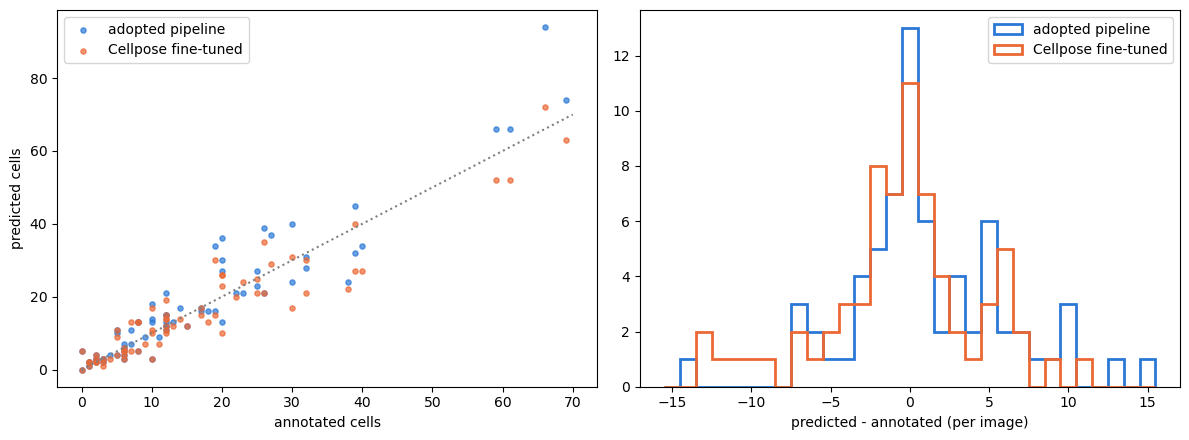

In [12]:
true_counts = np.array([labels.max() for labels in true_labels])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, color in [("adopted pipeline", "#2a78d6"), ("Cellpose fine-tuned", "#eb6834")]:
    predicted_counts = counts[name][0][:, 7]                 # column 7 = number of predicted objects
    axes[0].scatter(true_counts, predicted_counts, s=14, color=color, label=name, alpha=0.7)
    axes[1].hist(predicted_counts - true_counts, bins=np.arange(-15.5, 16.5), histtype="step", linewidth=2,
                 color=color, label=name)
axes[0].plot([0, 70], [0, 70], color="grey", linestyle=":")
axes[0].set_xlabel("annotated cells")
axes[0].set_ylabel("predicted cells")
axes[0].legend()
axes[1].set_xlabel("predicted - annotated (per image)")
axes[1].legend()
plt.tight_layout()
plt.show()

The predicted counts follow the annotated ones closely, from empty images to images with ~70 cells. The adopted pipeline
tends to count a few cells too many, Cellpose a few too few: the same different trade-off seen in section 8. The count is
simply the number of objects in the predicted mask (no correction), so mask and count always agree.

## 10. Examples

The two test images where the adopted pipeline does best and the two where it does worst (among images with at least 10
cells). Green: found cells (TP); red: objects that do not match an annotated cell (FP); yellow: annotated cells that were
not found (FN).

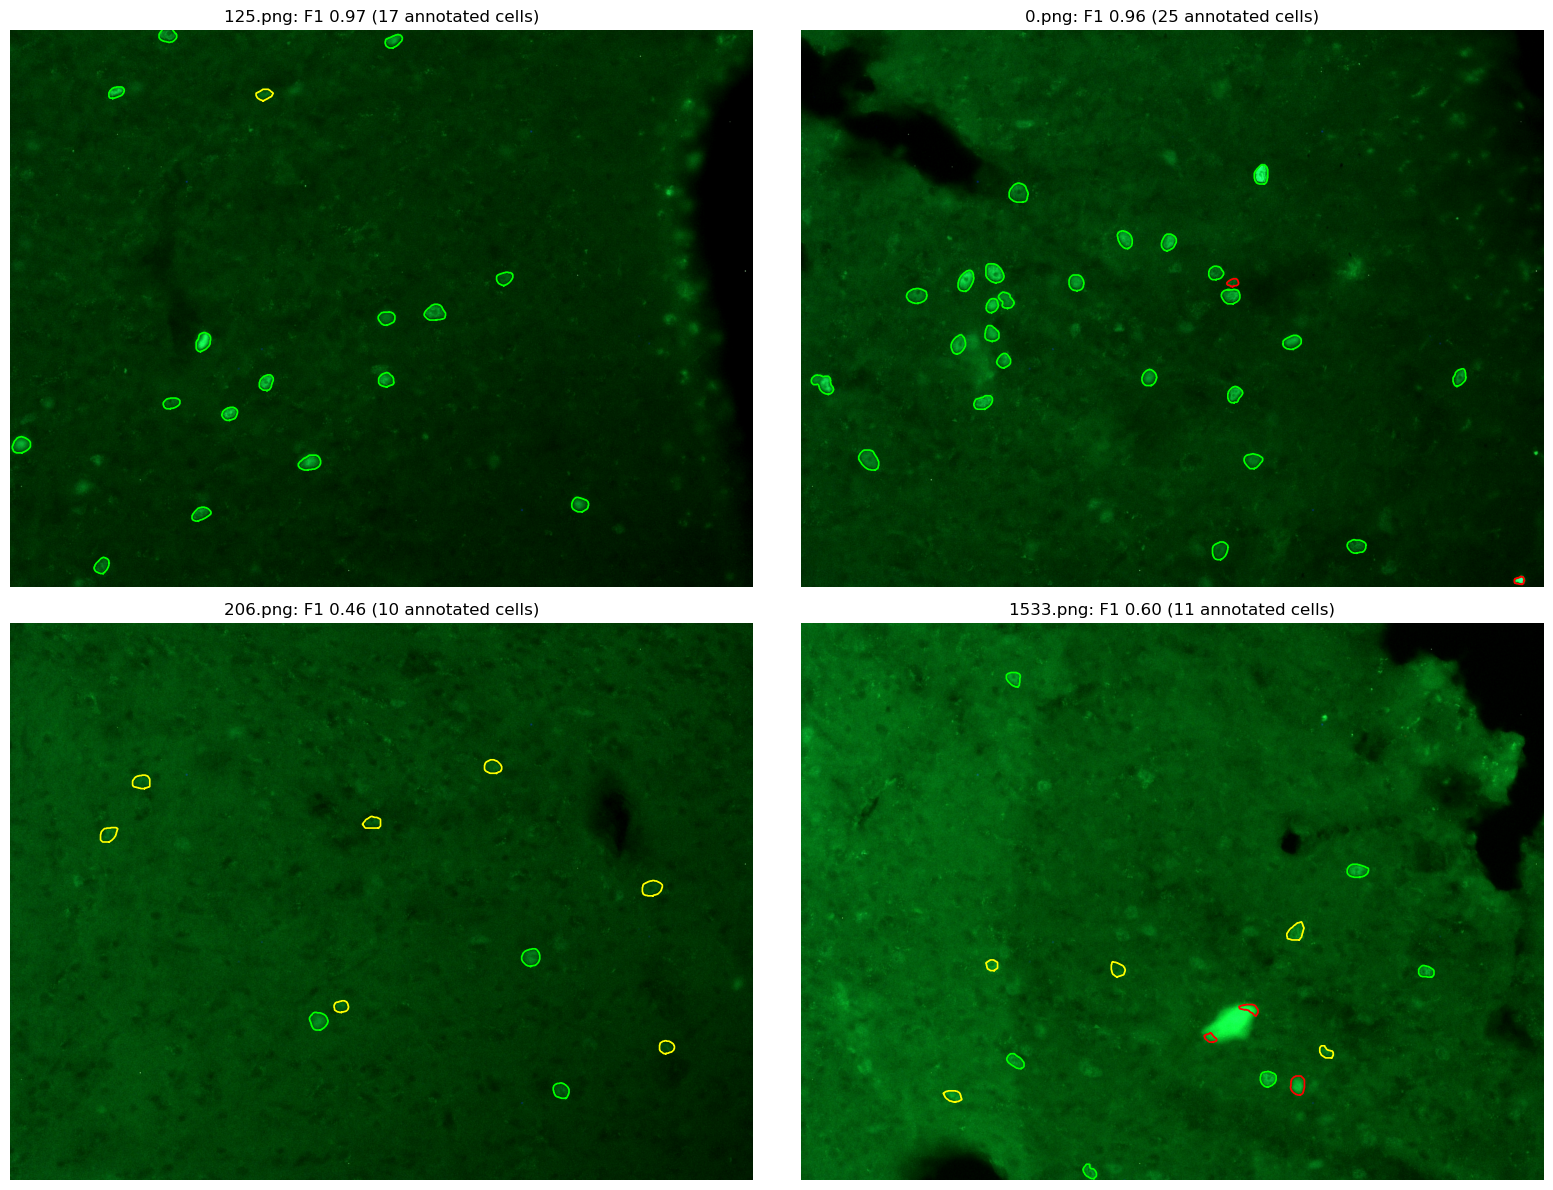

In [13]:
def draw_errors(ax, i):
    '''Found cells in green, false positives in red, missed annotated cells in yellow.'''
    labels = adopted_labels[i]
    inter, iou = overlap_tables(labels, true_labels[i])
    for k in range(1, labels.max() + 1):
        color = "lime" if (iou[k - 1] > 0.5).any() else "red"
        outline(ax, labels == k, color)
    for j in range(1, true_labels[i].max() + 1):
        if not (iou[:, j - 1] > 0.5).any():
            outline(ax, true_labels[i] == j, "yellow")

f1_per_image = []
for i in range(len(names)):
    tp, fp, fn = counts["adopted pipeline"][0][i][3:6]
    f1_per_image.append(2 * tp / max(2 * tp + fp + fn, 1))
f1_per_image = np.array(f1_per_image)
candidates = [i for i in range(len(names)) if true_counts[i] >= 10]
ranked = sorted(candidates, key=lambda i: f1_per_image[i])
chosen = ranked[-2:][::-1] + ranked[:2]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, i in zip(axes.ravel(), chosen):
    ax.imshow(show(images[i]))
    draw_errors(ax, i)
    ax.set_title(f"{names[i]}: F1 {f1_per_image[i]:.2f} ({true_counts[i]} annotated cells)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. Which errors remain

In [14]:
total = {"TP": 0, "FP isolated": 0, "FP partial": 0, "FN missed": 0, "FN partial": 0}
for labels, cells in zip(adopted_labels, true_labels):
    inter, iou = overlap_tables(labels, cells)
    for k in range(inter.shape[0]):
        if (iou[k] > 0.5).any():
            total["TP"] += 1
        elif inter[k].sum() == 0:
            total["FP isolated"] += 1
        else:
            total["FP partial"] += 1
    for j in range(inter.shape[1]):
        if (iou[:, j] > 0.5).any():
            continue
        if inter[:, j].sum() == 0:
            total["FN missed"] += 1
        else:
            total["FN partial"] += 1
print(total)
errors = total["FP isolated"] + total["FP partial"] + total["FN missed"] + total["FN partial"]
yes_no = total["FP isolated"] + total["FN missed"]
print(f"errors where the whole cell is extra or missing (yes/no decision): {yes_no} of {errors} ({100 * yes_no / errors:.0f}%)")

{'TP': 1012, 'FP isolated': 267, 'FP partial': 13, 'FN missed': 134, 'FN partial': 26}
errors where the whole cell is extra or missing (yes/no decision): 401 of 440 (91%)


Most of the remaining errors are not bad outlines but **yes/no decisions on whole cells**: objects predicted where nothing is
annotated, and annotated cells not predicted at all. As seen on the validation images (notebook 03), these are mostly faint
cells, where the annotation itself is uncertain (the protocol asks for a conservative choice and the decision is subjective);
many of the "false positives" look like real cells.

## 12. Conclusions and limits

| test set (70 images, 1172 cells) | value |
|---|---|
| object F1 (IoU > 0.5) | **0.821** [0.795, 0.847] |
| precision / recall | 0.783 / 0.863 |
| pixel Dice | 0.752 |
| count error (MAE) / bias | 4.1 cells per image / +1.7 |
| counter F1 (centres within 30 px) | 0.832 |

- A small network trained from scratch (1.3 M parameters, ~1 h of GPU training, ~3 s per image on a CPU) plus a simple
  post-processing reaches the level of Cellpose-SAM fine-tuned on the same images (no demonstrable difference), and is far
  better than classical thresholding and than Cellpose used out of the box.
- **Main limit: the labels.** Most remaining errors are faint cells where annotators themselves would disagree; a better model
  cannot fix inconsistent labels, and the measured scores are bounded by them.
- **Touching cells:** the watershed separates some of them, not all; methods that predict each cell as a separate instance
  (as Cellpose does) separate them better.
- **Future work:** instance-aware outputs (distance to the cell centre, or flows as in Cellpose) for the remaining merges;trasfer learning on yellow and red datasets.